(np.float64(17532.0), np.float64(17532.999305495996))

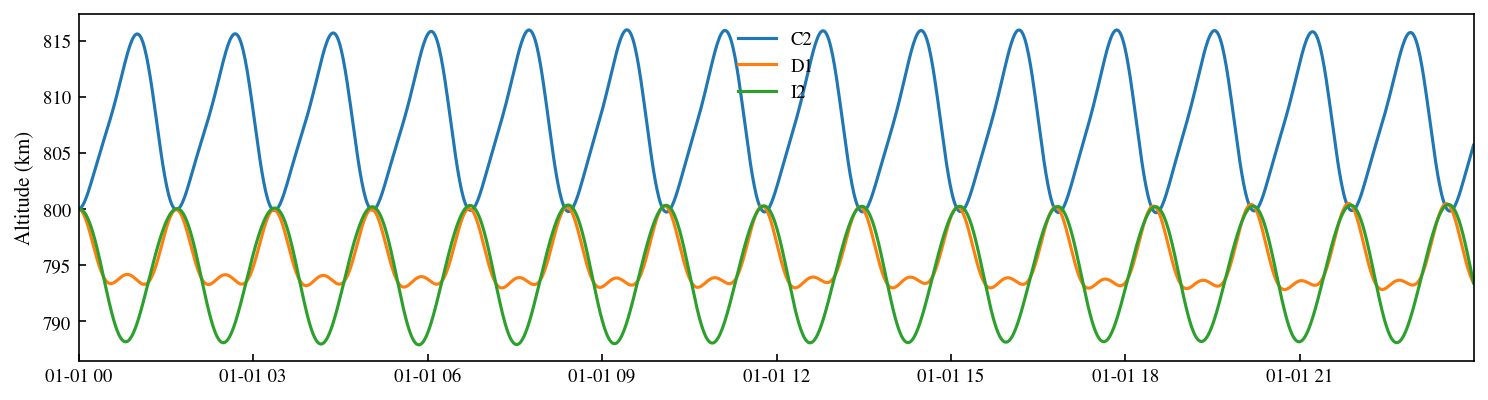

In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from SpaceBalls.postproc_EEI_estimation import check_EEI_consistency, get_full_output_var_hist, get_radial_measurement_arrays, get_jd_window_idxs, getnnz
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays
from SpaceBalls.sph_meshing import get_sphere_grid, lonlat_to_r
from SpaceBalls.utils import latlon_to_coord_name
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR

import string
letters = string.ascii_lowercase

matplotlib.rcParams.update({

    # Font
    "font.size": 10,
    "font.family": "STIXGeneral",  # A clean, professional font
    "mathtext.fontset": "stix",

    # Axes
    "axes.linewidth": 0.8,
    "axes.labelsize": 10,
    "axes.titlesize": 10,

    # Lines
    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    # Ticks
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Legend
    "legend.fontsize": 9,
    "legend.frameon": False,

    # Grid (usually off in publications)
    "axes.grid": False,

    # Figure
    "figure.dpi": 150
})

def load_map_file(dir, map_name):
    try:
        map_hist = np.load(os.path.join(dir, map_name+'.npy'))
    except FileNotFoundError:
        map_hist = np.loadtxt(os.path.join(dir, map_name+'.txt')).reshape((n_lat, n_lon, -1))
    
    return map_hist

sat_names = ['C2', 'D1', 'I2']
input_names = ['case_5_years_sc_' + tag for tag in sat_names]
n_sat = len(input_names)
altitude = 800  # TODO: make robust and get from input database

n_lon, n_lat = 360, 180
frame = 'SFF'
day_idx = 0

EEI_name = check_EEI_consistency(input_names)
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
r_grid = lonlat_to_r(lon_vec, lat_vec, altitude, "spherical")

# EEI_full_window = radiation_settings_from_EEI_truth_name(EEI_name)['jd_interval']
# jd_0 = EEI_full_window[0]

frame_tag = '_SFF' if frame=='SFF' else ''

# load truth
day_jd_hist = get_EEI_truth_daily_jd_arrays(EEI_name)[day_idx]
day_jd_window = [day_jd_hist[0], day_jd_hist[-1]]

net_780km_daily_hist = load_map_file(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, 'grid_'+str(n_lat)+'x'+str(n_lon), 
                                    'daily_hist_net_780km'+frame_tag), 'day_'+str(day_idx))

net_800km_daily_hist = load_map_file(os.path.join(MEDIA_DIR, 'true_EEI', EEI_name, 'grid_'+str(n_lat)+'x'+str(n_lon), 
                                    'daily_hist_net_800km'+frame_tag), 'day_'+str(day_idx))


jd_hist_array = get_full_output_var_hist(input_names, 'jd_vec')
radial_flux_meas_3D_arrays = get_radial_measurement_arrays(input_names, n_lon, n_lat, frame, meas='flux', mode='3D')

if frame=="ECEF":
    r_hist_array = get_full_output_var_hist(input_names, 'xyz_ecef')
elif frame=="SFF":
    r_hist_array = get_full_output_var_hist(input_names, 'xyz_sun_frame')

hlatlon_hist_array = get_full_output_var_hist(input_names, 'h_lat_lon'+frame_tag)

fig_alt, ax_alt = plt.subplots(figsize=(12,3))
for i in range(n_sat):
    jd_array = jd_hist_array[i]
    idxs = get_jd_window_idxs(jd_array, np.array([day_jd_window]))[0]
    ax_alt.plot(Plotter.jd_to_datetime(jd_array[idxs[0]:idxs[1]+1]), hlatlon_hist_array[i][idxs[0]:idxs[1]+1,0], label=sat_names[i])
ax_alt.set_ylabel('Altitude (km)')
ax_alt.legend()
ax_alt.set_xlim(Plotter.jd_to_datetime(day_jd_window[0]), Plotter.jd_to_datetime(day_jd_window[1]))


In [ ]:

all_n_meas_day = [None] * n_sat
all_3D_meas_arrays_day = [None] * n_sat
all_jd_arrays_day = [None] * n_sat
all_r_arrays_day = [None] * n_sat

for i in range(n_sat):
    first_last_idxs = get_jd_window_idxs(jd_hist_array[i], np.array([day_jd_window]))[0]
    meas_3D_array = radial_flux_meas_3D_arrays[i][:, :, first_last_idxs[0]:(first_last_idxs[1]+1)]
    
    all_3D_meas_arrays_day[i] = meas_3D_array.todense()
    all_n_meas_day[i] = getnnz(meas_3D_array, axis=2)
    all_jd_arrays_day[i] = jd_hist_array[i][first_last_idxs[0]:(first_last_idxs[1]+1)]
    all_r_arrays_day[i] = r_hist_array[i][first_last_idxs[0]:(first_last_idxs[1]+1), :]

total_n_meas_map = np.sum(all_n_meas_day, axis=0)
n_max = np.max(total_n_meas_map)
cell_idxs = np.where(total_n_meas_map > np.min([10, np.max(n_max-2)]))
#cell_idxs = [cell_idxs[0][0:10], cell_idxs[1][0:10]] # TODO: remove this line, just for testing

full_3D_meas_array = np.concatenate(all_3D_meas_arrays_day, axis=2)
full_jd_meas_array = np.concatenate(all_jd_arrays_day, axis=0)
full_r_array = np.concatenate(all_r_arrays_day, axis=0)

fig, axes = plt.subplots(3, 3, sharex=True, figsize=(12,5), layout="constrained")
axes = axes.flatten()   # easier indexing
norm = plt.Normalize(vmin=0, vmax=100)
n_plots = len(axes)

# randomly select n_plots from cell_idxs:
chosen_idxs = np.sort(np.random.choice(len(cell_idxs[0]), size=n_plots, replace=False))
cell_idxs = [cell_idxs[0][chosen_idxs], cell_idxs[1][chosen_idxs]]

for j, (lat_idx, lon_idx) in enumerate(zip(cell_idxs[0], cell_idxs[1])):

    lat_lon_pair = (lat_vec[lat_idx], lon_vec[lon_idx])
    print("lat_idx: ", lat_idx, " lon_idx: ", lon_idx)
    cell_meas_hist = full_3D_meas_array[lat_idx, lon_idx, :]
    idxs = np.where(cell_meas_hist != 0)[0]

    cell_meas_hist = cell_meas_hist[idxs]
    cell_jd_meas_hist = full_jd_meas_array[idxs]

    cell_center_r = r_grid[lat_idx, lon_idx]
    sat_r_hist = full_r_array[idxs, :]
    cell_center_offsets = np.linalg.norm(sat_r_hist - cell_center_r[None,:], axis=1)

    # plot
    datetime_array = Plotter.jd_to_datetime(day_jd_hist)

    ax = axes[j]
    ax.plot(datetime_array, net_800km_daily_hist[lat_idx, lon_idx, :], label='True flux 800km', color='k', lw=1.1)
    #ax.plot(datetime_array, net_780km_daily_hist[lat_idx, lon_idx, :], label='True flux 780km', color='b', lw=1.1, linestyle='--')
    ax.scatter(Plotter.jd_to_datetime(cell_jd_meas_hist), cell_meas_hist, label='Measurements', 
               c=norm(cell_center_offsets), cmap="autumn", marker='x', s=12)

    locator = mdates.AutoDateLocator(minticks=3, maxticks=7)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    ax.set_xlim(datetime_array[0], datetime_array[-1])
    #ax.set_ylabel('Flux (W/m$^2$)', fontsize=9)

    ax.text(
        0.02, 0.95,
        f"({letters[j]}): {latlon_to_coord_name(lat_lon_pair)}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        )
    )


fig.supylabel('Net flux (W/m$^2$)', fontsize=9)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="autumn"), ax=axes, orientation='vertical', 
             label='Distance from cell center (km)', fraction=0.02, pad=0.01)

# Collect all handles and labels from all axes to avoid duplicates
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create a single legend for the entire figure
# Use unique handles and labels for a clean legend
unique_labels = dict(zip(labels, handles))
fig.suptitle('  ')
fig.legend(unique_labels.values(), unique_labels.keys(), loc='upper center', ncols=3) # bbox_to_anchor=(1, 1)

#fig.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the legend


#fig.legend([curve_800, curve_780, scatter_meas], bbox_to_anchor=(0.5,1.02))


print("checkpoint")

In [ ]:
import numpy as np
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series, estimate_EEI_avg, get_all_orbital_sma_0
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
%matplotlib inline

EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))
mid_day_jd_array = get_mid_day_jd_array(EEI_name)
EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name, 360, 180)

SB_constellation = ['sc_A1', 'sc_A2', 'sc_A3', 'sc_C1', 'sc_C2', 'sc_C3']

combinations = itertools.combinations((SB_constellation), 3)

input_names = ['case_5_years_' + sc_name for sc_name in SB_constellation]
all_altitudes = get_all_orbital_sma_0(input_names) - constants.earth_radius(units='km')
assert(len(np.unique(all_altitudes))==1)

smoothing_windows_days = [1, 7, 30, 182, 365]
smoothing_windows_names = ['1-day', '1-week', '1-month', '6-month', '1-year']

for window_name, window_days in zip(smoothing_windows_names[3:], smoothing_windows_days[3:]):
    print(f"Running smooth estimate {window_days}-day window")
    print("")
    EEI_smooth_true = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=window_days)
    EEI_smooth_true_coarse = np.interp(mid_day_jd_array, full_jd_array, EEI_smooth_true)

    EEI_smooth_estimated = np.zeros_like(EEI_smooth_true_coarse)
    jd_windows = np.zeros((len(mid_day_jd_array), 2))
    for i, mid_day_jd in enumerate(mid_day_jd_array):
        jd_windows[i,:] = [
            max(mid_day_jd - window_days/2, mid_day_jd_array[0]  - 0.5),
            min(mid_day_jd + window_days/2, mid_day_jd_array[-1] + 0.5),
        ]
    
    EEI_smooth_estimated = estimate_EEI_avg('case_5_years', sc_names=SB_constellation, 
                                    altitude=np.unique(all_altitudes), jd_windows=jd_windows, 
                                    n_lon=360, n_lat=180, frame="SFF", fill_method="theta_s_fit_accurate",
                                    make_plots=False)
        
    Plotter.plot_time_series(mid_day_jd_array,
                        {'True EEI ('+window_name+' avg.)': EEI_smooth_true_coarse,
                        'Estimated EEI('+window_name+' avg.)': EEI_smooth_estimated},
                        f_width=2.5, f_height=0.5,
                        ylabel='Net TOA flux (W/m$^2$)',
                        y_scatter_dict={'$\phi(t)$ (W/m$^2$)': (full_jd_array, EEI_time_series_180x360)},
                        scatter_alpha=0.007,
                        title='Constellation_'+letter)
    
    Plotter.plot_time_series(mid_day_jd_array,
                        {'Estimation error': EEI_smooth_estimated-EEI_smooth_true_coarse},
                        f_width=2.5, f_height=0.5,
                        ylabel='Error (W/m$^2$)')


In [ ]:
import numpy as np
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays
from SpaceBalls.utils import normal_smoother
from SpaceBalls.plotter import Plotter
%matplotlib inline

EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))

EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name, 360, 180)
EEI_time_series_180x360_smooth = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=1)

smoothing_windows_days = [1, 7, 30, 365]
smoothing_windows_names = ['1-day', '1-week', '1-month', '1-year']
EEI_smooth_time_series_array = [normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=window) for window in smoothing_windows_days]

EEI_time_series_360x720 = get_true_EEI_time_series(EEI_name, 720, 360)
EEI_time_series_360x720_smooth = normal_smoother(EEI_time_series_360x720, full_jd_array, window_width_days=1)

EEI_smooth_dict = {window_name: EEI_smooth for (window_name, EEI_smooth) in zip(smoothing_windows_names, EEI_smooth_time_series_array)}
Plotter.plot_time_series(full_jd_array,
                        EEI_smooth_dict,
                        f_width=2.5, f_height=0.5,
                        ylabel='Avg. net TOA flux (W/m$^2$)')



In [ ]:
Plotter.plot_time_series(full_jd_array,
                         {'1-day avg. EEI': EEI_time_series_180x360_smooth},
                          f_width=2.5, f_height=0.5,
                          ylabel='Avg. net TOA flux (W/m$^2$)',
                          y_scatter_dict={'$\phi(t)$ (W/m$^2$)': (full_jd_array,EEI_time_series_180x360)},
                          scatter_alpha=0.007)

Plotter.plot_time_series(full_jd_array,
                         {'1-day avg. EEI (180x360 grid)': EEI_time_series_180x360_smooth,
                          '1-day avg. EEI (360x720 grid)': EEI_time_series_360x720_smooth},
                          f_width=2, f_height=0.7,
                          ylabel='Avg. net TOA flux (W/m$^2$)')

Plotter.plot_time_series(full_jd_array,
                         {'Diff. between 180x360 and 360x720 grid': EEI_time_series_180x360_smooth - EEI_time_series_360x720_smooth},
                          f_width=2, f_height=0.7,
                          ylabel='Diff. between 180x360 and 360x720 grid')

In [ ]:
import sys, os
import numpy as np
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import get_sphere_grid
from SpaceBalls.radiation_fluxes_preprocessing import get_file_names_and_existence
%matplotlib inline

EEI_truth_name = "EEI_truth_1"
n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
out_dir = os.path.join(MEDIA_DIR, 'true_EEI', EEI_truth_name, 'grid_'+str(n_lat)+'x'+str(n_lon))

# TOA
day_idx = 182
file_names, file_existences = get_file_names_and_existence(out_dir, 0, day_idx)
del(file_names['daily_hist_net_toa_lat_avg'])
del(file_names['daily_hist_net_toa_surf_avg'])

for fkey, fname in file_names.items():
    print(fname)
    if file_existences[fkey]:
        try:
            map = np.load(fname+'.npy')
        except:
            map = np.loadtxt(fname+'.txt')
            if len(map)>n_lon*n_lat:
                map = map.reshape((n_lat, n_lon, 1440))

        if len(np.shape(map))==3:
            Plotter.plot_geo_data(map[:,:,0], lon_edges_vec, lat_edges_vec, title=fkey)
            Plotter.plot_geo_data(map[:,:,700], lon_edges_vec, lat_edges_vec, title=fkey)
        elif len(np.shape(map))==2 and np.shape(map)==(n_lat, n_lon):
            Plotter.plot_geo_data(map, lon_edges_vec, lat_edges_vec, title=fkey)
        else:
            print(np.shape(map))

